Task 1 v2: Learn u and $\nabla u$ (Instantaneous Surrogate)

This notebook implements:
- input at time t: particle state $x_t$
- output at time t: [$u_t$, $\nabla u_t$]
- FLOWUnsteady still does $\mathcal{O}(N)$ state integration and time marching
- the Neural Operator replaces expensive velocity/gradient_velocity evaluation


In [1]:
from pathlib import Path
import json
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader

NOTEBOOK_VERSION = 'task1_v2'
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

CWD = Path.cwd().resolve()
if (CWD / 'final-2' / 'output').exists():
    BASE = CWD / 'final-2'
elif (CWD.name == 'notebooks') and (CWD.parent / 'output').exists():
    BASE = CWD.parent
else:
    BASE = CWD

DATA_PATH = BASE / 'output' / 'particle_ugradu_dataset.npz'
OUT_DIR = BASE / 'output' / 'task1_ugradu_training'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Notebook version:', NOTEBOOK_VERSION)
print('Base:', BASE)
print('DATA_PATH:', DATA_PATH)
print('Exists?:', DATA_PATH.exists())
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
if not DATA_PATH.exists():
    raise FileNotFoundError('Run preprocess_data.py with TASK1_TARGET_MODE="ugradu" first')


Notebook version: task1_v2
Base: /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/final-2
DATA_PATH: /home/dysco/Neeraj/Flow-reconstruction-in-VPM-using-FNO/final-2/output/particle_ugradu_dataset.npz
Exists?: True
Device: cpu


In [2]:
# Load dataset + dual split setup + normalization sanity checks

ds = np.load(DATA_PATH, allow_pickle=True)
feature_names = [str(x) for x in ds['feature_names'].tolist()]
target_names = [str(x) for x in ds['target_names'].tolist()]

frame_ranges = list(ds['frame_ranges'])
frame_contexts = list(ds['frame_contexts'])

# Backward-compatible keys
train_frame_ids = ds['train_frame_ids'].astype(np.int64)
val_frame_ids = ds['val_frame_ids'].astype(np.int64)
test_frame_ids = ds['test_frame_ids'].astype(np.int64)

# New dual split keys (if present)
val_id_frame_ids = ds['val_id_frame_ids'].astype(np.int64) if 'val_id_frame_ids' in ds.files else np.array([], dtype=np.int64)
val_ood_frame_ids = ds['val_ood_frame_ids'].astype(np.int64) if 'val_ood_frame_ids' in ds.files else val_frame_ids
test_ood_frame_ids = ds['test_ood_frame_ids'].astype(np.int64) if 'test_ood_frame_ids' in ds.files else test_frame_ids

if val_id_frame_ids.size == 0:
    # Fallback for old datasets: derive ID-val from training cases.
    rng = np.random.default_rng(SEED)
    idx = np.asarray(train_frame_ids, dtype=np.int64)
    perm = rng.permutation(idx.shape[0])
    n_val_id = max(8, int(0.2 * idx.shape[0])) if idx.shape[0] > 1 else 0
    n_val_id = min(max(1, idx.shape[0] - 1), n_val_id) if idx.shape[0] > 1 else 0
    val_id_frame_ids = np.sort(idx[perm[:n_val_id]]) if n_val_id > 0 else np.array([], dtype=np.int64)
    train_frame_ids = np.sort(idx[perm[n_val_id:]]) if n_val_id > 0 else idx

train_cases = [str(x) for x in ds['train_cases'].tolist()] if 'train_cases' in ds.files else []
val_cases = [str(x) for x in ds['val_cases'].tolist()] if 'val_cases' in ds.files else []
test_cases = [str(x) for x in ds['test_cases'].tolist()] if 'test_cases' in ds.files else []

out_mean = ds['out_mean'].astype(np.float32)
out_std = ds['out_std'].astype(np.float32)

use_explicit_conditioning = bool(np.asarray(ds.get('use_explicit_conditioning', np.asarray(False))).reshape(-1)[0])
conditioning_channel_names = [str(x) for x in ds.get('conditioning_channel_names', np.asarray([], dtype=object)).tolist()]
conditioning_active = [str(x) for x in ds.get('conditioning_active_channel_names', np.asarray(conditioning_channel_names, dtype=object)).tolist()]

split_stats = {}
if 'split_stats' in ds.files:
    raw_stats = ds['split_stats'].reshape(-1)[0]
    split_stats = raw_stats.item() if hasattr(raw_stats, 'item') else dict(raw_stats)

# Preferred: each frame is one graph sample
if 'inputs_by_frame_norm' in ds.files and 'targets_by_frame_norm' in ds.files:
    X_frames_norm = [np.asarray(x, dtype=np.float32) for x in ds['inputs_by_frame_norm'].tolist()]
    Y_frames_norm = [np.asarray(y, dtype=np.float32) for y in ds['targets_by_frame_norm'].tolist()]
    X_frames_raw = [np.asarray(x, dtype=np.float32) for x in ds['inputs_by_frame'].tolist()]
    Y_frames_raw = [np.asarray(y, dtype=np.float32) for y in ds['targets_by_frame'].tolist()]
    data_mode = 'frame_graph'
else:
    X_all_norm = ds['inputs_t_norm'].astype(np.float32)
    Y_all_norm = ds['targets_ugradu_norm'].astype(np.float32)
    X_all_raw = ds['inputs_t'].astype(np.float32)
    Y_all_raw = ds['targets_ugradu'].astype(np.float32)

    X_frames_norm, Y_frames_norm = [], []
    X_frames_raw, Y_frames_raw = [], []
    for case, fr, s, e, n in frame_ranges:
        s, e = int(s), int(e)
        X_frames_norm.append(X_all_norm[s:e])
        Y_frames_norm.append(Y_all_norm[s:e])
        X_frames_raw.append(X_all_raw[s:e])
        Y_frames_raw.append(Y_all_raw[s:e])
    data_mode = 'flat_fallback_to_frames'

n_frames = len(X_frames_norm)
in_dim = int(X_frames_norm[0].shape[1])
out_dim = int(Y_frames_norm[0].shape[1])

print('data mode                     :', data_mode)
print('n_frames                      :', n_frames)
print('input feature dim             :', in_dim)
print('target dim                    :', out_dim)
print('feature_names                 :', feature_names)
print('target_names                  :', target_names)
print('train/val_id/val_ood/test_ood :', len(train_frame_ids), len(val_id_frame_ids), len(val_ood_frame_ids), len(test_ood_frame_ids))
print('train/val/test cases          :', train_cases, val_cases, test_cases)
print('explicit conditioning         :', use_explicit_conditioning)
print('conditioning channels         :', conditioning_channel_names)
print('active conditioning channels  :', conditioning_active)

# Geom mode inference for logs.
geom_present = [k for k in feature_names if k.startswith('geom_')]
if len(geom_present) == 0:
    GEOM_MODE = 'none'
elif geom_present == ['geom_dist']:
    GEOM_MODE = 'dist_only'
else:
    GEOM_MODE = 'all'
print('inferred GEOM_MODE            :', GEOM_MODE)

geom_dist_idx = feature_names.index('geom_dist') if 'geom_dist' in feature_names else None
print('geom_dist_idx                 :', geom_dist_idx)

# Channel-wise variance checks on train split.
train_rows = ds['train_rows'].astype(np.int64) if 'train_rows' in ds.files else None
X_flat_raw = ds['inputs_t'].astype(np.float32) if 'inputs_t' in ds.files else None
if train_rows is not None and X_flat_raw is not None:
    print('\n[train channel variance summary]')
    dead = []
    for i, name in enumerate(feature_names):
        var_i = float(np.var(X_flat_raw[train_rows, i]))
        print(f'  {i:02d} {name:20s} var={var_i:.3e}')
        if var_i <= 1e-12:
            dead.append(name)

    if use_explicit_conditioning:
        # Some channels can be constant by physics/design (e.g., freestream_y = 0 in x-z inflow setup).
        allowed_constant = {'freestream_y'}
        dead_cond = [c for c in conditioning_active if c in dead and c not in allowed_constant]
        dead_cond_allowed = [c for c in conditioning_active if c in dead and c in allowed_constant]

        if len(dead_cond_allowed) > 0:
            print('[cond] allowing constant-by-design channels:', dead_cond_allowed)

        if len(dead_cond) > 0:
            raise RuntimeError(
                'Conditioning channels are active but variance is ~0 on training rows: '
                + ', '.join(dead_cond)
                + '. Fix case metadata and rebuild dataset.'
            )

if split_stats:
    print('\n[split stats from preprocessing]')
    for k in ['train_id', 'val_id', 'val_ood', 'test_ood']:
        if k in split_stats:
            print(f'  {k}:', split_stats[k])


data mode                     : frame_graph
n_frames                      : 1394
input feature dim             : 17
target dim                    : 12
feature_names                 : ['x', 'y', 'z', 'Gamma_x', 'Gamma_y', 'Gamma_z', 'sigma', 'geom_dist', 'geom_nx', 'geom_ny', 'geom_nz', 'geom_body_near', 'angle_of_attack', 'freestream_x', 'freestream_y', 'freestream_z', 'phase']
target_names                  : ['velocity_x', 'velocity_y', 'velocity_z', 'gradUx_x', 'gradUx_y', 'gradUx_z', 'gradUy_x', 'gradUy_y', 'gradUy_z', 'gradUz_x', 'gradUz_y', 'gradUz_z']
train/val_id/val_ood/test_ood : 637 160 398 199
train/val/test cases          : ['1', '2', '10', '11'] ['8', '7'] ['9']
explicit conditioning         : True
conditioning channels         : ['angle_of_attack', 'freestream_x', 'freestream_y', 'freestream_z', 'phase']
active conditioning channels  : ['angle_of_attack', 'freestream_x', 'freestream_y', 'freestream_z', 'phase']
inferred GEOM_MODE            : all
geom_dist_idx            

In [3]:
# Dataset class: one sample = one coherent frame graph

class FrameDataset(Dataset):
    def __init__(self, X_frames_norm, Y_frames_norm, X_frames_raw, frame_ids, frame_contexts):
        self.X_frames_norm = X_frames_norm
        self.Y_frames_norm = Y_frames_norm
        self.X_frames_raw = X_frames_raw
        self.frame_ids = [int(i) for i in frame_ids]
        self.frame_contexts = frame_contexts

    def __len__(self):
        return len(self.frame_ids)

    def __getitem__(self, idx):
        fid = self.frame_ids[idx]
        x = torch.from_numpy(self.X_frames_norm[fid])
        y = torch.from_numpy(self.Y_frames_norm[fid])
        x_raw = torch.from_numpy(self.X_frames_raw[fid])

        ctx = self.frame_contexts[fid]
        case = str(ctx.get('case', ''))
        fr = str(ctx.get('frame', ctx.get('fr', '')))
        n = int(ctx.get('n_particles', x.shape[0]))

        meta = {
            'frame_id': fid,
            'case': case,
            'fr': fr,
            'n': n,
            'phase': float(ctx.get('phase', 0.0)),
            'aoa_deg': float(ctx.get('aoa_deg', 0.0)),
            'freestream': ctx.get('freestream', [0.0, 0.0, 0.0]),
        }
        return x, y, x_raw, meta


def collate_frame(batch):
    xs, ys, xrs, ms = zip(*batch)
    return list(xs), list(ys), list(xrs), list(ms)

train_ds = FrameDataset(X_frames_norm, Y_frames_norm, X_frames_raw, train_frame_ids, frame_contexts)
val_id_ds = FrameDataset(X_frames_norm, Y_frames_norm, X_frames_raw, val_id_frame_ids, frame_contexts)
val_ood_ds = FrameDataset(X_frames_norm, Y_frames_norm, X_frames_raw, val_ood_frame_ids, frame_contexts)
test_ood_ds = FrameDataset(X_frames_norm, Y_frames_norm, X_frames_raw, test_ood_frame_ids, frame_contexts)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=collate_frame)
val_id_loader = DataLoader(val_id_ds, batch_size=1, shuffle=False, collate_fn=collate_frame)
val_ood_loader = DataLoader(val_ood_ds, batch_size=1, shuffle=False, collate_fn=collate_frame)
test_ood_loader = DataLoader(test_ood_ds, batch_size=1, shuffle=False, collate_fn=collate_frame)

# Aliases for backward compatibility with older plotting cells.
val_ds = val_ood_ds
test_ds = test_ood_ds
val_loader = val_ood_loader
test_loader = test_ood_loader

print('dataset lens train/val_id/val_ood/test_ood:', len(train_ds), len(val_id_ds), len(val_ood_ds), len(test_ood_ds))
print('sample frame particle count:', train_ds[0][0].shape[0])


dataset lens train/val_id/val_ood/test_ood: 637 160 398 199
sample frame particle count: 201


[connectivity] split=train case=1 frame=000101 n_used=6000
radius | mean_deg | median_deg | min_deg | max_deg
 0.080 |    12.34 |       9.00 |       0 |      59
 0.120 |    26.16 |      20.00 |       1 |      90
 0.180 |    58.14 |      47.00 |       5 |     168
 0.250 |   107.01 |      92.00 |      27 |     250
 0.350 |   197.47 |     184.00 |      42 |     400


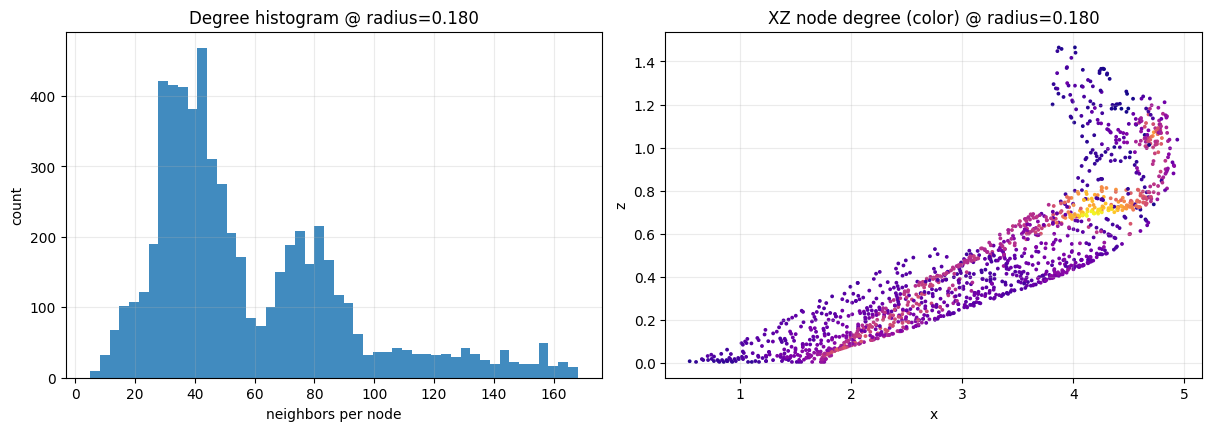

In [4]:

# Graph connectivity sanity (radius-neighbor diagnostics)
# This helps check whether GNO radius/depth are under-connecting or over-connecting the graph.

from scipy.spatial import cKDTree

CONNECTIVITY_SAMPLE_SPLIT = 'train'   # 'train' | 'val' | 'test'
CONNECTIVITY_SAMPLE_INDEX = 100         # index inside selected split dataset
CONNECTIVITY_RADII = [0.08, 0.12, 0.18, 0.25, 0.35]
MAX_POINTS_FOR_CONN = 6000            # subsample for speed/clarity

split_map = {'train': train_ds, 'val': val_ds, 'test': test_ds}
conn_ds = split_map[CONNECTIVITY_SAMPLE_SPLIT]

x_norm, y_norm, x_raw_frame, meta = conn_ds[CONNECTIVITY_SAMPLE_INDEX]
coords = x_raw_frame[:, :3].numpy()

if coords.shape[0] > MAX_POINTS_FOR_CONN:
    g = torch.Generator().manual_seed(42)
    idx = torch.randperm(coords.shape[0], generator=g)[:MAX_POINTS_FOR_CONN].numpy()
    coords = coords[idx]

print(f"[connectivity] split={CONNECTIVITY_SAMPLE_SPLIT} case={meta['case']} frame={meta['fr']} n_used={coords.shape[0]}")

tree = cKDTree(coords)
conn_stats = []
for r in CONNECTIVITY_RADII:
    deg = tree.query_ball_point(coords, r=float(r), return_length=True) - 1  # exclude self
    conn_stats.append((float(r), float(np.mean(deg)), float(np.median(deg)), int(np.min(deg)), int(np.max(deg))))

print('radius | mean_deg | median_deg | min_deg | max_deg')
for r, m, md, mn, mx in conn_stats:
    print(f'{r:6.3f} | {m:8.2f} | {md:10.2f} | {mn:7d} | {mx:7d}')

# Plot degree distribution at one reference radius (closest to current GNO radius)
ref_r = CONNECTIVITY_RADII[len(CONNECTIVITY_RADII)//2]
deg_ref = tree.query_ball_point(coords, r=float(ref_r), return_length=True) - 1

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
axs[0].hist(deg_ref, bins=50, color='tab:blue', alpha=0.85)
axs[0].set_title(f'Degree histogram @ radius={ref_r:.3f}')
axs[0].set_xlabel('neighbors per node')
axs[0].set_ylabel('count')
axs[0].grid(alpha=0.25)

sample_n = min(1500, coords.shape[0])
sel = np.random.default_rng(42).choice(coords.shape[0], size=sample_n, replace=False)
axs[1].scatter(coords[sel,0], coords[sel,2], s=3, c=deg_ref[sel], cmap='plasma')
axs[1].set_title(f'XZ node degree (color) @ radius={ref_r:.3f}')
axs[1].set_xlabel('x')
axs[1].set_ylabel('z')
axs[1].grid(alpha=0.25)
plt.show()


# at frame = 100
# r=0.18 looks like a solid balance
# Plots depict connectivity of the graphs, and about message passing. Stability/convergence vs cost


In [5]:
# Model: GNO for instantaneous u/gradU regression
import inspect

try:
    from neuralop.layers.gno_block import GNOBlock
except Exception as exc:
    raise RuntimeError('Need neuralop with GNOBlock') from exc


def rel_l2(pred, tgt, eps=1e-12):
    d = (pred - tgt).reshape(pred.shape[0], -1)
    t = tgt.reshape(tgt.shape[0], -1)
    return (torch.linalg.norm(d, dim=1) / torch.linalg.norm(t, dim=1).clamp_min(eps)).mean()


class UGradUGNO(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=96, n_layers=3, radius=0.12, dropout=0.04):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, hidden),
        )

        sig = inspect.signature(GNOBlock.__init__)
        p = sig.parameters
        extra = {}
        if 'use_torch_scatter_reduce' in p:
            try:
                import torch_scatter  # noqa: F401
                extra['use_torch_scatter_reduce'] = True
            except Exception:
                extra['use_torch_scatter_reduce'] = False
        if 'use_open3d_neighbor_search' in p:
            try:
                import open3d  # noqa: F401
                extra['use_open3d_neighbor_search'] = True
            except Exception:
                extra['use_open3d_neighbor_search'] = False

        self.backend_flags = extra
        if extra:
            print('GNO backend flags:', extra)

        self.blocks = nn.ModuleList([
            GNOBlock(
                in_channels=hidden,
                out_channels=hidden,
                coord_dim=3,
                radius=radius,
                transform_type='linear',
                reduction='mean',
                pos_embedding_type='transformer',
                pos_embedding_channels=16,
                channel_mlp_layers=[hidden, hidden, hidden],
                **extra,
            ) for _ in range(n_layers)
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(n_layers)])
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        pos = x[:, :3]  # x,y,z
        h = self.enc(x)

        # Reuse neighbor search across blocks with same radius.
        neighbors_by_radius = {}
        for blk, norm in zip(self.blocks, self.norms):
            r = float(blk.radius)
            if r not in neighbors_by_radius:
                neighbors_by_radius[r] = blk.neighbor_search(data=pos, queries=pos, radius=r)
            neighbors = neighbors_by_radius[r]

            pos_in = blk.pos_embedding(pos) if blk.pos_embedding is not None else pos
            u = blk.integral_transform(y=pos_in, x=pos_in, neighbors=neighbors, f_y=h)
            if u.ndim == 3 and u.shape[0] == 1:
                u = u.squeeze(0)
            h = norm(h + u)  # residual block
        return self.head(h)


# Balanced-speed defaults (can be increased later for final quality run).
GNO_HIDDEN = 96
GNO_LAYERS = 3
GNO_RADIUS = 0.12
MODEL_DROPOUT = 0.04

model = UGradUGNO(in_dim, out_dim, hidden=GNO_HIDDEN, n_layers=GNO_LAYERS, radius=GNO_RADIUS, dropout=MODEL_DROPOUT).to(DEVICE)
print('params:', sum(p.numel() for p in model.parameters() if p.requires_grad))
print('GNO config:', {'hidden': GNO_HIDDEN, 'layers': GNO_LAYERS, 'radius': GNO_RADIUS, 'dropout': MODEL_DROPOUT})

if getattr(model, 'backend_flags', {}):
    if (not model.backend_flags.get('use_open3d_neighbor_search', False)) or (not model.backend_flags.get('use_torch_scatter_reduce', False)):
        print('[perf] warning: fast neighbor/reduction backends are partially unavailable; large node caps may be slow.')


GNO backend flags: {'use_torch_scatter_reduce': False, 'use_open3d_neighbor_search': False}
params: 152172
GNO config: {'hidden': 96, 'layers': 3, 'radius': 0.12, 'dropout': 0.04}
[perf] warning: fast neighbor/reduction backends are partially unavailable; large node caps may be slow.


In [6]:
# Optimizer + training settings
opt_cls = None
try:
    import neuralop.training as nt
    opt_cls = getattr(nt, 'AdamW', None) or getattr(nt, 'Adam', None)
except Exception:
    pass
if opt_cls is None:
    opt_cls = torch.optim.AdamW

# Profiles: 'fast_sanity' | 'balanced_gpu' | 'quality'
SPEED_PROFILE = 'fast_sanity'

PROFILE_CFG = {
    'fast_sanity': {
        'EPOCHS': 6,
        'MAX_NODES_START': 768,
        'MAX_NODES_FINAL': 1536,
        'FRAMES_PER_EPOCH': 10,
        'VAL_FRAMES_LIMIT': 6,
        'EVAL_EVERY': 1,
        'TEST_EVERY': 3,
        'PRINT_EVERY_STEPS': 3,
        'EARLY_STOP_PATIENCE': 3,
        'MAX_PARTICLES_CPU_CUTOFF': 6000,
        'EVAL_NODE_CAP': 1024,
    },
    'balanced_gpu': {
        'EPOCHS': 60,
        'MAX_NODES_START': 1024,
        'MAX_NODES_FINAL': 4096,
        'FRAMES_PER_EPOCH': 28,
        'VAL_FRAMES_LIMIT': 10,
        'EVAL_EVERY': 5,
        'TEST_EVERY': 10,
        'PRINT_EVERY_STEPS': 6,
        'EARLY_STOP_PATIENCE': 6,
        'MAX_PARTICLES_CPU_CUTOFF': 12000,
        'EVAL_NODE_CAP': 1536,
    },
    'quality': {
        'EPOCHS': 80,
        'MAX_NODES_START': 2048,
        'MAX_NODES_FINAL': 8192,
        'FRAMES_PER_EPOCH': 64,
        'VAL_FRAMES_LIMIT': 24,
        'EVAL_EVERY': 5,
        'TEST_EVERY': 5,
        'PRINT_EVERY_STEPS': 8,
        'EARLY_STOP_PATIENCE': 8,
        'MAX_PARTICLES_CPU_CUTOFF': 20000,
        'EVAL_NODE_CAP': 3072,
    },
}

if SPEED_PROFILE not in PROFILE_CFG:
    raise ValueError(f'Unknown SPEED_PROFILE={SPEED_PROFILE}. Choose from {list(PROFILE_CFG)}')

_cfg = PROFILE_CFG[SPEED_PROFILE]
EPOCHS = int(_cfg['EPOCHS'])
MAX_NODES_START = int(_cfg['MAX_NODES_START'])
MAX_NODES_FINAL = int(_cfg['MAX_NODES_FINAL'])
FRAMES_PER_EPOCH = int(_cfg['FRAMES_PER_EPOCH'])
VAL_FRAMES_LIMIT = int(_cfg['VAL_FRAMES_LIMIT'])
EVAL_EVERY = int(_cfg['EVAL_EVERY'])
TEST_EVERY = int(_cfg['TEST_EVERY'])
PRINT_EVERY_STEPS = int(_cfg['PRINT_EVERY_STEPS'])
EARLY_STOP_PATIENCE = int(_cfg['EARLY_STOP_PATIENCE'])
MAX_PARTICLES_CPU_CUTOFF = int(_cfg['MAX_PARTICLES_CPU_CUTOFF'])
EVAL_NODE_CAP = int(_cfg['EVAL_NODE_CAP'])
GRAD_CLIP_NORM = 1.0

# Weight decay acts as explicit regularization.
opt = opt_cls(model.parameters(), lr=3e-4, weight_decay=3e-5)
sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=5e-6)

# Loss settings for multi-target regression.
LOSS_KIND = 'huber'      # 'huber' | 'mse' | 'logcosh'
HUBER_BETA = 0.06
VEL_WEIGHT = 1.0
GRAD_WEIGHT_STAGE1 = 0.25
GRAD_WEIGHT_STAGE2 = 0.90
GRAD_WEIGHT_STAGE2_EPOCH = max(20, EPOCHS // 2)

# Near-body reweighting: w = 1 + alpha * exp(-dist / scale)
USE_NEAR_BODY_WEIGHT = True
NEAR_ALPHA = 1.2
NEAR_SCALE = 0.15

# Near-body oversampling while downsampling large frames
USE_NEAR_BODY_OVERSAMPLE = False

# Mixed precision for speed on GPU
USE_AMP = (DEVICE.type == 'cuda')
AMP_DTYPE = torch.bfloat16 if (USE_AMP and torch.cuda.is_bf16_supported()) else torch.float16
scaler_enabled = bool(USE_AMP and AMP_DTYPE == torch.float16)
try:
    scaler = torch.amp.GradScaler('cuda', enabled=scaler_enabled)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=scaler_enabled)
autocast_kwargs = dict(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP)

if DEVICE.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision('high')
    except Exception:
        pass

GEOM_MODE = globals().get('GEOM_MODE', 'frame_graph')

print('config:', {
    'SPEED_PROFILE': SPEED_PROFILE,
    'EPOCHS': EPOCHS,
    'MAX_NODES_START': MAX_NODES_START,
    'MAX_NODES_FINAL': MAX_NODES_FINAL,
    'FRAMES_PER_EPOCH': FRAMES_PER_EPOCH,
    'VAL_FRAMES_LIMIT': VAL_FRAMES_LIMIT,
    'EVAL_EVERY': EVAL_EVERY,
    'TEST_EVERY': TEST_EVERY,
    'LOSS_KIND': LOSS_KIND,
    'VEL_WEIGHT': VEL_WEIGHT,
    'GRAD_WEIGHT_STAGE1': GRAD_WEIGHT_STAGE1,
    'GRAD_WEIGHT_STAGE2': GRAD_WEIGHT_STAGE2,
    'GRAD_WEIGHT_STAGE2_EPOCH': GRAD_WEIGHT_STAGE2_EPOCH,
    'USE_NEAR_BODY_WEIGHT': USE_NEAR_BODY_WEIGHT,
    'USE_NEAR_BODY_OVERSAMPLE': USE_NEAR_BODY_OVERSAMPLE,
    'USE_AMP': USE_AMP,
    'MAX_PARTICLES_CPU_CUTOFF': MAX_PARTICLES_CPU_CUTOFF,
    'EVAL_NODE_CAP': EVAL_NODE_CAP,
    'AMP_DTYPE': str(AMP_DTYPE),
    'GNO_HIDDEN': int(globals().get('GNO_HIDDEN', -1)),
    'GNO_LAYERS': int(globals().get('GNO_LAYERS', -1)),
    'GNO_RADIUS': float(globals().get('GNO_RADIUS', -1.0)),
    'GEOM_MODE': GEOM_MODE,
})


config: {'SPEED_PROFILE': 'fast_sanity', 'EPOCHS': 6, 'MAX_NODES_START': 768, 'MAX_NODES_FINAL': 1536, 'FRAMES_PER_EPOCH': 10, 'VAL_FRAMES_LIMIT': 6, 'EVAL_EVERY': 1, 'TEST_EVERY': 3, 'LOSS_KIND': 'huber', 'VEL_WEIGHT': 1.0, 'GRAD_WEIGHT_STAGE1': 0.25, 'GRAD_WEIGHT_STAGE2': 0.9, 'GRAD_WEIGHT_STAGE2_EPOCH': 20, 'USE_NEAR_BODY_WEIGHT': True, 'USE_NEAR_BODY_OVERSAMPLE': False, 'USE_AMP': False, 'MAX_PARTICLES_CPU_CUTOFF': 6000, 'EVAL_NODE_CAP': 1024, 'AMP_DTYPE': 'torch.float16', 'GNO_HIDDEN': 96, 'GNO_LAYERS': 3, 'GNO_RADIUS': 0.12, 'GEOM_MODE': 'all'}


In [ ]:
# Training + validation (ID/OOD-aware)
history = []
best_val_id = np.inf
best_state = None
best_epoch = 0
patience_count = 0


def _pointwise_loss(pred, tgt):
    if LOSS_KIND == 'mse':
        return (pred - tgt) ** 2
    if LOSS_KIND == 'logcosh':
        return torch.log(torch.cosh(pred - tgt + 1e-12))
    return F.smooth_l1_loss(pred, tgt, reduction='none', beta=HUBER_BETA)


def _sample_weights_from_raw(x_raw):
    if (geom_dist_idx is None) or (not USE_NEAR_BODY_WEIGHT):
        return torch.ones(x_raw.shape[0], device=x_raw.device)
    d = x_raw[:, geom_dist_idx].clamp_min(0.0)
    w = 1.0 + NEAR_ALPHA * torch.exp(-d / NEAR_SCALE)
    return w


def _weighted_channel_mean(loss_nc, w_n):
    wn = w_n / (w_n.mean().clamp_min(1e-12))
    return (loss_nc * wn[:, None]).mean(dim=0)


def split_loss(pred, tgt, x_raw, grad_weight):
    pt = _pointwise_loss(pred, tgt)
    w = _sample_weights_from_raw(x_raw)
    ch = _weighted_channel_mean(pt, w)
    vel_loss = ch[:3].mean()
    grad_loss = ch[3:].mean()
    total = VEL_WEIGHT * vel_loss + grad_weight * grad_loss
    return total, {
        'total': float(total.item()),
        'vel': float(vel_loss.item()),
        'grad': float(grad_loss.item()),
        'w_mean': float(w.mean().item()),
        'w_max': float(w.max().item()),
    }


def current_node_cap(epoch):
    if EPOCHS <= 1:
        return MAX_NODES_FINAL
    alpha = min(max((epoch - 1) / float(max(EPOCHS - 1, 1)), 0.0), 1.0)
    cap = int(round((1.0 - alpha) * MAX_NODES_START + alpha * MAX_NODES_FINAL))
    return max(256, cap)


def pick_nodes(x, y, x_raw, max_nodes):
    n = x.shape[0]
    if n <= max_nodes:
        return x, y, x_raw

    if (geom_dist_idx is None) or (not USE_NEAR_BODY_OVERSAMPLE):
        idx = torch.randperm(n, device=x.device)[:max_nodes]
        return x[idx], y[idx], x_raw[idx]

    d = x_raw[:, geom_dist_idx].clamp_min(0.0)
    pr = torch.exp(-d / NEAR_SCALE)
    pr = pr / pr.sum().clamp_min(1e-12)
    idx = torch.multinomial(pr, num_samples=max_nodes, replacement=False)
    return x[idx], y[idx], x_raw[idx]

def pre_subsample_cpu(x, y, x_raw, max_particles_cpu):
    """Bound pathological large frames before any GPU transfer."""
    n = x.shape[0]
    if n <= max_particles_cpu:
        return x, y, x_raw
    idx = torch.randperm(n)[:max_particles_cpu]
    return x[idx], y[idx], x_raw[idx]


def eval_loader(loader, max_frames=64, grad_weight=1.0, max_nodes_eval=None, max_particles_cpu=12000):
    model.eval()
    rels, mses = [], []
    vel_rels, grad_rels = [], []
    total_losses, vel_losses, grad_losses = [], [], []
    if max_nodes_eval is None:
        max_nodes_eval = MAX_NODES_FINAL

    with torch.no_grad():
        for b, (xs, ys, xrs, ms) in enumerate(loader):
            if b >= max_frames:
                break
            x, y, xr = xs[0], ys[0], xrs[0]
            x, y, xr = pre_subsample_cpu(x, y, xr, max_particles_cpu=max_particles_cpu)
            x, y, xr = pick_nodes(x, y, xr, max_nodes_eval)
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            xr = xr.to(DEVICE, non_blocking=True)

            with torch.autocast(**autocast_kwargs):
                p = model(x)
                _, parts = split_loss(p, y, xr, grad_weight=grad_weight)

            total_losses.append(parts['total'])
            vel_losses.append(parts['vel'])
            grad_losses.append(parts['grad'])

            rels.append(float(rel_l2(p.float().unsqueeze(0), y.float().unsqueeze(0)).item()))
            mses.append(float(torch.mean((p.float() - y.float()) ** 2).item()))
            vel_rels.append(float(rel_l2(p[:, :3].float().unsqueeze(0), y[:, :3].float().unsqueeze(0)).item()))
            grad_rels.append(float(rel_l2(p[:, 3:].float().unsqueeze(0), y[:, 3:].float().unsqueeze(0)).item()))

    return {
        'rel_l2': float(np.mean(rels)) if rels else np.nan,
        'mse': float(np.mean(mses)) if mses else np.nan,
        'vel_rel_l2': float(np.mean(vel_rels)) if vel_rels else np.nan,
        'grad_rel_l2': float(np.mean(grad_rels)) if grad_rels else np.nan,
        'loss_total': float(np.mean(total_losses)) if total_losses else np.nan,
        'loss_vel': float(np.mean(vel_losses)) if vel_losses else np.nan,
        'loss_grad': float(np.mean(grad_losses)) if grad_losses else np.nan,
    }


def eval_mean_baseline(loader, max_frames=64):
    y_train = np.concatenate([Y_frames_norm[int(i)] for i in train_frame_ids], axis=0)
    ybar = torch.from_numpy(np.mean(y_train, axis=0, keepdims=True)).float().to(DEVICE)
    rels = []
    with torch.no_grad():
        for b, (xs, ys, xrs, ms) in enumerate(loader):
            if b >= max_frames:
                break
            y = ys[0].to(DEVICE)
            pred = ybar.repeat(y.shape[0], 1)
            rels.append(float(rel_l2(pred.unsqueeze(0), y.unsqueeze(0)).item()))
    return float(np.mean(rels)) if rels else np.nan


print('Smoke test...')
x0, y0, xr0, _ = train_ds[0]
x0, y0, xr0 = pre_subsample_cpu(x0, y0, xr0, max_particles_cpu=MAX_PARTICLES_CPU_CUTOFF)
cap0 = min(current_node_cap(1), x0.shape[0])
idx0 = torch.randperm(x0.shape[0])[:cap0] if x0.shape[0] > cap0 else None
if idx0 is not None:
    x0, y0, xr0 = x0[idx0], y0[idx0], xr0[idx0]
x0, y0, xr0 = x0.to(DEVICE), y0.to(DEVICE), xr0.to(DEVICE)
with torch.autocast(**autocast_kwargs):
    p0 = model(x0)
    L0, _ = split_loss(p0, y0, xr0, grad_weight=GRAD_WEIGHT_STAGE1)
if scaler.is_enabled():
    scaler.scale(L0).backward()
else:
    L0.backward()
model.zero_grad(set_to_none=True)
print('Smoke OK:', float(L0.item()))

mean_baseline_val_id = eval_mean_baseline(val_id_loader, max_frames=VAL_FRAMES_LIMIT)
print(f'mean baseline val_id rel-L2: {mean_baseline_val_id:.4f}')

for ep in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()

    grad_weight = GRAD_WEIGHT_STAGE1 if ep < GRAD_WEIGHT_STAGE2_EPOCH else GRAD_WEIGHT_STAGE2
    max_nodes_ep = current_node_cap(ep)

    epoch_losses = []
    epoch_vel_losses = []
    epoch_grad_losses = []
    epoch_rel = []
    step_times = []

    n_pick = min(FRAMES_PER_EPOCH, len(train_ds))
    picks = np.random.choice(len(train_ds), size=n_pick, replace=False)

    for step, ridx in enumerate(picks, start=1):
        t_step = time.time()
        x, y, xr, meta = train_ds[int(ridx)]
        x, y, xr = pre_subsample_cpu(x, y, xr, max_particles_cpu=MAX_PARTICLES_CPU_CUTOFF)
        x, y, xr = pick_nodes(x, y, xr, max_nodes_ep)
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        xr = xr.to(DEVICE, non_blocking=True)

        opt.zero_grad(set_to_none=True)
        with torch.autocast(**autocast_kwargs):
            pred = model(x)
            loss, parts = split_loss(pred, y, xr, grad_weight=grad_weight)

        if scaler.is_enabled():
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(opt)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()

        epoch_losses.append(parts['total'])
        epoch_vel_losses.append(parts['vel'])
        epoch_grad_losses.append(parts['grad'])
        epoch_rel.append(float(rel_l2(pred.detach().float().unsqueeze(0), y.float().unsqueeze(0)).item()))
        step_times.append(time.time() - t_step)

        if step % PRINT_EVERY_STEPS == 0:
            print(
                f"[ep {ep:03d}] step {step:03d}/{n_pick} "
                f"loss={parts['total']:.4e} vel={parts['vel']:.4e} grad={parts['grad']:.4e} "
                f"cap={max_nodes_ep} step_sec={step_times[-1]:.2f}",
                flush=True,
            )

    sch.step()

    tr_loss = float(np.mean(epoch_losses))
    tr_vel = float(np.mean(epoch_vel_losses))
    tr_grad = float(np.mean(epoch_grad_losses))
    tr_rel = float(np.mean(epoch_rel))

    row = {
        'epoch': ep,
        'lr': float(opt.param_groups[0]['lr']),
        'grad_weight': float(grad_weight),
        'max_nodes_epoch': int(max_nodes_ep),
        'train_loss': tr_loss,
        'train_rel_l2': tr_rel,
        'train_vel_loss': tr_vel,
        'train_grad_loss': tr_grad,
        'mean_step_sec': float(np.mean(step_times)) if step_times else np.nan,
        'epoch_sec': float(time.time() - t0),
        'val_id_rel_l2': np.nan,
        'val_ood_rel_l2': np.nan,
        'test_ood_rel_l2': np.nan,
    }

    if (ep % EVAL_EVERY) == 0:
        teval = time.time()
        eval_nodes = min(max_nodes_ep, EVAL_NODE_CAP)
        m_val_id = eval_loader(val_id_loader, max_frames=VAL_FRAMES_LIMIT, grad_weight=grad_weight, max_nodes_eval=eval_nodes, max_particles_cpu=MAX_PARTICLES_CPU_CUTOFF)
        m_val_ood = eval_loader(val_ood_loader, max_frames=VAL_FRAMES_LIMIT, grad_weight=grad_weight, max_nodes_eval=eval_nodes, max_particles_cpu=MAX_PARTICLES_CPU_CUTOFF)

        row.update({
            'val_id_rel_l2': m_val_id['rel_l2'],
            'val_id_mse': m_val_id['mse'],
            'val_id_vel_rel_l2': m_val_id['vel_rel_l2'],
            'val_id_grad_rel_l2': m_val_id['grad_rel_l2'],
            'val_id_loss_total': m_val_id['loss_total'],
            'val_ood_rel_l2': m_val_ood['rel_l2'],
            'val_ood_mse': m_val_ood['mse'],
            'val_ood_vel_rel_l2': m_val_ood['vel_rel_l2'],
            'val_ood_grad_rel_l2': m_val_ood['grad_rel_l2'],
            'eval_sec_val': float(time.time() - teval),
        })

        if (ep % TEST_EVERY) == 0:
            ttest = time.time()
            m_test_ood = eval_loader(test_ood_loader, max_frames=VAL_FRAMES_LIMIT, grad_weight=grad_weight, max_nodes_eval=eval_nodes, max_particles_cpu=MAX_PARTICLES_CPU_CUTOFF)
            row.update({
                'test_ood_rel_l2': m_test_ood['rel_l2'],
                'test_ood_mse': m_test_ood['mse'],
                'test_ood_vel_rel_l2': m_test_ood['vel_rel_l2'],
                'test_ood_grad_rel_l2': m_test_ood['grad_rel_l2'],
                'eval_sec_test': float(time.time() - ttest),
            })

        # best checkpoint is chosen on val_id by design
        if m_val_id['rel_l2'] < best_val_id:
            best_val_id = m_val_id['rel_l2']
            best_epoch = ep
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1

        msg = (
            f"[epoch {ep:03d}] train_rel={tr_rel:.4e} "
            f"val_id={m_val_id['rel_l2']:.4e} val_ood={m_val_ood['rel_l2']:.4e} "
            f"lr={row['lr']:.2e} cap={max_nodes_ep} "
            f"step_sec={row['mean_step_sec']:.2f} epoch_sec={row['epoch_sec']:.1f} eval_nodes={eval_nodes} "
            f"patience={patience_count}/{EARLY_STOP_PATIENCE}"
        )
        if np.isfinite(row['test_ood_rel_l2']):
            msg += f" test_ood={row['test_ood_rel_l2']:.4e}"
        print(msg, flush=True)

        if patience_count >= EARLY_STOP_PATIENCE:
            history.append(row)
            print('Early stopping triggered on val_id plateau.')
            break

    history.append(row)

if best_state is not None:
    model.load_state_dict(best_state)

summary = {
    'notebook_version': NOTEBOOK_VERSION,
    'best_val_id_rel_l2': float(best_val_id),
    'best_epoch': int(best_epoch),
    'mean_baseline_val_id_rel_l2': float(mean_baseline_val_id),
    'epochs_requested': int(EPOCHS),
    'epochs_ran': int(len(history)),
    'device': str(DEVICE),
    'train_frames': int(len(train_ds)),
    'val_id_frames': int(len(val_id_ds)),
    'val_ood_frames': int(len(val_ood_ds)),
    'test_ood_frames': int(len(test_ood_ds)),
    'geom_mode': GEOM_MODE,
    'loss_kind': LOSS_KIND,
    'speed_profile': SPEED_PROFILE,
}
print(json.dumps(summary, indent=2))


Smoke test...
Smoke OK: 0.1821727305650711
mean baseline val_id rel-L2: 1.0000
[ep 001] step 003/10 loss=9.1103e-01 vel=8.0841e-01 grad=4.1044e-01 cap=768 step_sec=1.02
[ep 001] step 006/10 loss=8.9000e-01 vel=7.9391e-01 grad=3.8435e-01 cap=768 step_sec=1.19
[ep 001] step 009/10 loss=5.1322e-01 vel=4.2364e-01 grad=3.5833e-01 cap=768 step_sec=0.46
[epoch 001] train_rel=1.0028e+00 val_id=9.9993e-01 val_ood=1.0619e+00 lr=2.80e-04 cap=768 step_sec=0.70 epoch_sec=7.0 eval_nodes=768 patience=0/3
[ep 002] step 003/10 loss=7.5729e-01 vel=6.7157e-01 grad=3.4284e-01 cap=922 step_sec=0.50
[ep 002] step 006/10 loss=5.0908e-01 vel=4.1657e-01 grad=3.7006e-01 cap=922 step_sec=0.55
[ep 002] step 009/10 loss=9.3547e-01 vel=7.7055e-01 grad=6.5967e-01 cap=922 step_sec=0.50
[epoch 002] train_rel=9.9956e-01 val_id=9.9479e-01 val_ood=1.0927e+00 lr=2.26e-04 cap=922 step_sec=1.30 epoch_sec=13.0 eval_nodes=922 patience=0/3
[ep 003] step 003/10 loss=1.1178e+00 vel=9.1475e-01 grad=8.1223e-01 cap=1075 step_sec=0.

In [ ]:
# Efficient model export/checkpoint cell (run after training cell)
from pathlib import Path
import json
import torch

EXPORT_DIR = OUT_DIR / 'checkpoints'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Use the best validation weights if available.
best_cpu_state = best_state if best_state is not None else {k: v.detach().cpu() for k, v in model.state_dict().items()}

# 1) Compact inference weights (FP16 where safe) for fast load + smaller file size.
weights_fp16 = {}
for k, v in best_cpu_state.items():
    t = v.detach().cpu().contiguous()
    if torch.is_floating_point(t):
        t = t.to(torch.float16)
    weights_fp16[k] = t

# Prefer safetensors if available; fallback to torch .pt zip serialization.
infer_path = None
infer_format = None
try:
    from safetensors.torch import save_file as save_safetensors
    infer_path = EXPORT_DIR / 'best_task1_ugradu_gno_fp16.safetensors'
    save_safetensors(weights_fp16, str(infer_path))
    infer_format = 'safetensors'
except Exception:
    infer_path = EXPORT_DIR / 'best_task1_ugradu_gno_fp16.pt'
    torch.save(weights_fp16, infer_path, _use_new_zipfile_serialization=True)
    infer_format = 'torch_pt_zip'

# 2) Full resume checkpoint (model + optimizer + scheduler + scaler + history).
resume_path = EXPORT_DIR / 'resume_checkpoint_full.pt'
resume_ckpt = {
    'model_state_dict': {k: v.detach().cpu().contiguous() for k, v in best_cpu_state.items()},
    'optimizer_state_dict': opt.state_dict(),
    'scheduler_state_dict': sch.state_dict() if 'sch' in globals() and sch is not None else None,
    'scaler_state_dict': scaler.state_dict() if 'scaler' in globals() and scaler is not None else None,
    'history': history,
    'summary': summary if 'summary' in globals() else {},
    'feature_names': feature_names,
    'target_names': target_names,
    'note': 'Full checkpoint for exact training resume.',
}
torch.save(resume_ckpt, resume_path, _use_new_zipfile_serialization=True)

# 3) Small JSON metadata for reproducibility.
meta_path = EXPORT_DIR / 'export_metadata.json'
meta = {
    'inference_checkpoint': str(infer_path),
    'inference_format': infer_format,
    'resume_checkpoint': str(resume_path),
    'input_dim': int(in_dim),
    'output_dim': int(out_dim),
    'device_trained': str(DEVICE),
    'best_val_rel_l2': float(best_val_id),
    'n_history_rows': int(len(history)),
}
meta_path.write_text(json.dumps(meta, indent=2))

mb = lambda p: (Path(p).stat().st_size / (1024**2)) if Path(p).exists() else -1.0
print('Saved inference checkpoint:', infer_path, f'({mb(infer_path):.2f} MB)')
print('Saved resume checkpoint   :', resume_path, f'({mb(resume_path):.2f} MB)')
print('Saved metadata            :', meta_path)

# Learn how are checkpoints of model saved, and how can we implement continual training effectively


In [ ]:
# Plot cache + helpers (post-training only; model weights remain unchanged)

PLOT_FIELD_CMAP = 'viridis'
PLOT_ERROR_SIGNED_CMAP = 'RdBu_r'
PLOT_ERROR_ABS_CMAP = 'magma'
PLOT_DPI = 300
PLANE_LIST = [('xy', 0, 1), ('xz', 0, 2), ('yz', 1, 2)]


def denorm_out(y_norm):
    return y_norm * out_std + out_mean


def pick_plot_sample_index(frame_ids, ranges, min_nodes=2048, quantile=0.70):
    counts = np.asarray([int(ranges[int(fid)][4]) for fid in frame_ids], dtype=np.int64)
    valid = np.where(counts >= int(min_nodes))[0]
    if len(valid) == 0:
        valid = np.where(counts > 1)[0]
    if len(valid) == 0:
        return 0, counts
    k = int(np.clip(round(quantile * (len(valid) - 1)), 0, len(valid) - 1))
    return int(valid[k]), counts


def plane_grid(coords, values, ax_i, ax_j, bins=180):
    xi = coords[:, ax_i]
    xj = coords[:, ax_j]
    x_edges = np.linspace(float(np.min(xi)), float(np.max(xi)), bins + 1)
    y_edges = np.linspace(float(np.min(xj)), float(np.max(xj)), bins + 1)
    sum_w, _, _ = np.histogram2d(xi, xj, bins=[x_edges, y_edges], weights=values)
    cnt, _, _ = np.histogram2d(xi, xj, bins=[x_edges, y_edges])
    with np.errstate(invalid='ignore', divide='ignore'):
        mean = np.divide(sum_w, cnt, out=np.full_like(sum_w, np.nan, dtype=np.float64), where=cnt > 0)
    extent = [x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]]
    return mean.T, extent


def robust_limits(arrays, q_low=0.02, q_high=0.98, floor=None):
    vals = []
    for a in arrays:
        x = np.asarray(a)
        x = x[np.isfinite(x)]
        if x.size > 0:
            vals.append(x.reshape(-1))
    if len(vals) == 0:
        return 0.0, 1.0
    v = np.concatenate(vals)
    vmin = float(np.quantile(v, q_low))
    vmax = float(np.quantile(v, q_high))
    if floor is not None:
        vmin = max(vmin, float(floor))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        vmin = float(np.nanmin(v))
        vmax = float(np.nanmax(v))
        if vmin >= vmax:
            vmax = vmin + 1e-6
    return vmin, vmax


def select_plot_frame(split_name, split_ds, split_frame_ids, min_nodes=2048, max_nodes=22000, quantile=0.70):
    ds_idx, counts = pick_plot_sample_index(split_frame_ids, frame_ranges, min_nodes=min_nodes, quantile=quantile)
    x_norm, y_norm, x_raw_frame, meta = split_ds[ds_idx]

    if x_norm.shape[0] > max_nodes:
        g = torch.Generator().manual_seed(42)
        idx = torch.randperm(x_norm.shape[0], generator=g)[:max_nodes]
        x_norm = x_norm[idx]
        y_norm = y_norm[idx]
        x_raw_frame = x_raw_frame[idx]

    with torch.no_grad():
        y_pred_norm = model(x_norm.to(DEVICE)).float().cpu().numpy()

    y_true = denorm_out(y_norm.numpy())
    y_pred = denorm_out(y_pred_norm)
    err = y_pred - y_true

    xr = x_raw_frame.numpy()
    coords = xr[:, :3].astype(np.float32)

    gamma_cols = [feature_names.index(k) for k in ['Gamma_x', 'Gamma_y', 'Gamma_z'] if k in feature_names]
    sigma_col = feature_names.index('sigma') if 'sigma' in feature_names else None

    gamma_mag = np.linalg.norm(xr[:, gamma_cols], axis=1) if len(gamma_cols) == 3 else np.zeros(coords.shape[0], dtype=np.float32)
    sigma = xr[:, sigma_col] if sigma_col is not None else np.zeros(coords.shape[0], dtype=np.float32)
    pos_mag = np.linalg.norm(coords, axis=1)

    u_true = np.linalg.norm(y_true[:, :3], axis=1)
    u_pred = np.linalg.norm(y_pred[:, :3], axis=1)
    u_err = (u_pred - u_true)
    u_abs_err = np.abs(u_err)

    grad_true = np.linalg.norm(y_true[:, 3:], axis=1)
    grad_pred = np.linalg.norm(y_pred[:, 3:], axis=1)
    grad_err = (grad_pred - grad_true)
    grad_abs_err = np.abs(grad_err)

    return {
        'split': split_name,
        'ds_index': int(ds_idx),
        'meta': meta,
        'coords': coords,
        'y_true': y_true,
        'y_pred': y_pred,
        'error': err,
        'u_true': u_true,
        'u_pred': u_pred,
        'u_err': u_err,
        'u_abs_err': u_abs_err,
        'grad_true': grad_true,
        'grad_pred': grad_pred,
        'grad_err': grad_err,
        'grad_abs_err': grad_abs_err,
        'gamma': gamma_mag,
        'sigma': sigma,
        'pos': pos_mag,
        'n_frame': int(meta['n']),
        'n_plot': int(coords.shape[0]),
        'frame_counts': counts,
    }


def plot_three_plane_compare(sample, true_key, pred_key, err_key, title_prefix, save_name, bins=180):
    coords = sample['coords']
    tval = sample[true_key]
    pval = sample[pred_key]
    evals = sample[err_key]
    absvals = np.abs(evals)

    fig, axs = plt.subplots(4, 3, figsize=(13.8, 14.2), constrained_layout=True)

    true_imgs, pred_imgs, err_imgs, abs_err_imgs = [], [], [], []
    extents = []
    for _, ai, aj in PLANE_LIST:
        t_img, ext = plane_grid(coords, tval, ai, aj, bins=bins)
        p_img, _ = plane_grid(coords, pval, ai, aj, bins=bins)
        e_img, _ = plane_grid(coords, evals, ai, aj, bins=bins)
        a_img, _ = plane_grid(coords, absvals, ai, aj, bins=bins)
        true_imgs.append(t_img); pred_imgs.append(p_img); err_imgs.append(e_img); abs_err_imgs.append(a_img)
        extents.append(ext)

    field_vmin, field_vmax = robust_limits(true_imgs + pred_imgs, q_low=0.02, q_high=0.98)
    err_abs = max(abs(robust_limits(err_imgs, q_low=0.02, q_high=0.98)[0]), abs(robust_limits(err_imgs, q_low=0.02, q_high=0.98)[1]))
    err_abs = max(err_abs, 1e-8)
    abs_vmin, abs_vmax = robust_limits(abs_err_imgs, q_low=0.02, q_high=0.98, floor=0.0)

    plane_names = ['XY', 'XZ', 'YZ']
    for col in range(3):
        ext = extents[col]
        t_img = true_imgs[col]
        p_img = pred_imgs[col]
        e_img = err_imgs[col]
        a_img = abs_err_imgs[col]

        im_t = axs[0, col].imshow(t_img, origin='lower', extent=ext, aspect='auto', cmap=PLOT_FIELD_CMAP, vmin=field_vmin, vmax=field_vmax)
        im_p = axs[1, col].imshow(p_img, origin='lower', extent=ext, aspect='auto', cmap=PLOT_FIELD_CMAP, vmin=field_vmin, vmax=field_vmax)
        im_e = axs[2, col].imshow(e_img, origin='lower', extent=ext, aspect='auto', cmap=PLOT_ERROR_SIGNED_CMAP, vmin=-err_abs, vmax=err_abs)
        im_a = axs[3, col].imshow(a_img, origin='lower', extent=ext, aspect='auto', cmap=PLOT_ERROR_ABS_CMAP, vmin=abs_vmin, vmax=abs_vmax)

        axs[0, col].set_title(f'True {plane_names[col]}')
        axs[1, col].set_title(f'Pred {plane_names[col]}')
        axs[2, col].set_title(f'Signed Error {plane_names[col]}')
        axs[3, col].set_title(f'Abs Error {plane_names[col]}')

        for r in range(4):
            axs[r, col].set_xlabel(plane_names[col][0].lower())
            axs[r, col].set_ylabel(plane_names[col][1].lower())

    for r, im in zip([0, 1, 2, 3], [im_t, im_p, im_e, im_a]):
        for c in range(3):
            plt.colorbar(im, ax=axs[r, c], fraction=0.046, pad=0.02)

    info = sample['meta']
    fig.suptitle(
        f"{title_prefix} | split={sample['split']} case={info['case']} frame={info['fr']} "
        f"n_plot={sample['n_plot']} (positions are input particle coordinates)",
        fontsize=12,
    )
    out_path = OUT_DIR / save_name
    fig.savefig(out_path, dpi=PLOT_DPI, bbox_inches='tight')
    plt.show()
    print('[saved]', out_path)


def plot_input_planes(sample, save_name, bins=180):
    coords = sample['coords']
    gamma = sample['gamma']
    sigma = sample['sigma']
    pos = sample['pos']
    fields = [('Gamma magnitude', gamma), ('sigma', sigma), ('|position|', pos)]

    fig, axs = plt.subplots(3, 3, figsize=(13.8, 11.8), constrained_layout=True)
    for r, (title, values) in enumerate(fields):
        imgs, extents = [], []
        for _, ai, aj in PLANE_LIST:
            img, ext = plane_grid(coords, values, ai, aj, bins=bins)
            imgs.append(img); extents.append(ext)
        vmin, vmax = robust_limits(imgs, q_low=0.02, q_high=0.98)
        for c, name in enumerate(['XY', 'XZ', 'YZ']):
            im = axs[r, c].imshow(imgs[c], origin='lower', extent=extents[c], aspect='auto', cmap=PLOT_FIELD_CMAP, vmin=vmin, vmax=vmax)
            axs[r, c].set_title(f'{title} on {name}')
            axs[r, c].set_xlabel(name[0].lower())
            axs[r, c].set_ylabel(name[1].lower())
            plt.colorbar(im, ax=axs[r, c], fraction=0.046, pad=0.02)

    fig.suptitle(f"Input feature maps | split={sample['split']} (positions fixed from input particles)", fontsize=12)
    out_path = OUT_DIR / save_name
    fig.savefig(out_path, dpi=PLOT_DPI, bbox_inches='tight')
    plt.show()
    print('[saved]', out_path)


def compute_split_metrics():
    return {
        'train': eval_loader(train_loader, max_frames=VAL_FRAMES_LIMIT, grad_weight=1.0, max_nodes_eval=MAX_NODES_FINAL),
        'val_id': eval_loader(val_id_loader, max_frames=VAL_FRAMES_LIMIT, grad_weight=1.0, max_nodes_eval=MAX_NODES_FINAL),
        'val_ood': eval_loader(val_ood_loader, max_frames=VAL_FRAMES_LIMIT, grad_weight=1.0, max_nodes_eval=MAX_NODES_FINAL),
        'test_ood': eval_loader(test_ood_loader, max_frames=VAL_FRAMES_LIMIT, grad_weight=1.0, max_nodes_eval=MAX_NODES_FINAL),
    }


if best_state is not None:
    model.load_state_dict(best_state)

PLOT_CACHE = {
    'train': select_plot_frame('train', train_ds, train_frame_ids),
    'val_id': select_plot_frame('val_id', val_id_ds, val_id_frame_ids),
    'val': select_plot_frame('val_ood', val_ood_ds, val_ood_frame_ids),
    'test': select_plot_frame('test_ood', test_ood_ds, test_ood_frame_ids),
}

# Save summary for downstream scripts.
final_metrics = compute_split_metrics()
summary.update({
    'final_train_rel_l2': float(final_metrics['train']['rel_l2']),
    'final_val_id_rel_l2': float(final_metrics['val_id']['rel_l2']),
    'final_val_ood_rel_l2': float(final_metrics['val_ood']['rel_l2']),
    'final_test_ood_rel_l2': float(final_metrics['test_ood']['rel_l2']),
})

(OUT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2))
(OUT_DIR / 'history.json').write_text(json.dumps(history, indent=2))
print('[saved]', OUT_DIR / 'summary.json')


In [ ]:
# Snippet: convergence curves (train + val_id + val_ood + test_ood)

rows_eval = [h for h in history if 'val_id_rel_l2' in h]
if len(rows_eval) == 0:
    raise RuntimeError('No evaluation rows found in history.')

epochs = [h['epoch'] for h in rows_eval]
cmap = plt.get_cmap(PLOT_FIELD_CMAP)

fig, axs = plt.subplots(1, 2, figsize=(14.0, 4.6), constrained_layout=True)

axs[0].plot(epochs, [h['train_loss'] for h in rows_eval], color=cmap(0.20), lw=2.0, label='train total loss')
axs[0].plot(epochs, [h['val_id_rel_l2'] for h in rows_eval], color=cmap(0.45), lw=2.0, label='val_id rel-L2')
axs[0].plot(epochs, [h['val_ood_rel_l2'] for h in rows_eval], color=cmap(0.70), lw=2.0, label='val_ood rel-L2')
axs[0].plot(epochs, [h['test_ood_rel_l2'] for h in rows_eval], color=cmap(0.90), lw=2.0, label='test_ood rel-L2')
axs[0].axhline(summary['mean_baseline_val_id_rel_l2'], color='black', ls='--', lw=1.2, label='mean baseline (val_id)')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss / Relative L2')
axs[0].set_title('Convergence (ID vs OOD)')
axs[0].grid(alpha=0.25)
axs[0].legend(frameon=False)

axs[1].plot(epochs, [h['max_nodes_epoch'] for h in rows_eval], color='tab:purple', lw=2.0, label='max nodes / frame')
axs[1].plot(epochs, [h['lr'] for h in rows_eval], color='tab:orange', lw=2.0, label='learning rate')
axs[1].set_xlabel('Epoch')
axs[1].set_title('Dynamic node cap + LR schedule')
axs[1].grid(alpha=0.25)
axs[1].legend(frameon=False)

out_path = OUT_DIR / 'convergence_train_val_id_val_ood_test_ood.png'
fig.savefig(out_path, dpi=PLOT_DPI, bbox_inches='tight')
plt.show()
print('[saved]', out_path)


In [ ]:
# Snippet: split-wise error metrics (train / val_id / val_ood / test_ood)

split_metrics = compute_split_metrics()
for _k in ['train', 'val_id', 'val_ood', 'test_ood']:
    _m = split_metrics[_k]
    print(f"{_k.upper()}: rel_l2={_m['rel_l2']:.4f}, vel_rel={_m['vel_rel_l2']:.4f}, grad_rel={_m['grad_rel_l2']:.4f}, mse={_m['mse']:.4e}")

splits = ['train', 'val_id', 'val_ood', 'test_ood']
x = np.arange(len(splits))
cmap = plt.get_cmap(PLOT_FIELD_CMAP)
bar_colors = [cmap(0.15), cmap(0.40), cmap(0.65), cmap(0.90)]

fig, axs = plt.subplots(1, 3, figsize=(16.5, 4.4), constrained_layout=True)
metric_defs = [
    ('rel_l2', 'Relative L2 (all outputs)'),
    ('vel_rel_l2', 'Relative L2 (velocity u)'),
    ('grad_rel_l2', 'Relative L2 (gradU)'),
]

for ax, (mk, title) in zip(axs, metric_defs):
    vals = [split_metrics[s][mk] for s in splits]
    bars = ax.bar(x, vals, color=bar_colors, width=0.70)
    ax.set_xticks(x, [s.upper() for s in splits], rotation=20)
    ax.set_ylabel('Relative L2')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2.0, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

out_path = OUT_DIR / 'split_error_metrics_train_val_id_val_ood_test_ood.png'
fig.savefig(out_path, dpi=PLOT_DPI, bbox_inches='tight')
plt.show()
print('[saved]', out_path)


In [ ]:
# Snippet: parity + error-vs-target diagnostics (OOD-focused)

def collect_uv_samples(loader, max_frames=24):
    model.eval()
    y_true_all = []
    y_pred_all = []
    with torch.no_grad():
        for b, (xs, ys, xrs, ms) in enumerate(loader):
            if b >= max_frames:
                break
            x = xs[0].to(DEVICE)
            y = ys[0].to(DEVICE)
            with torch.autocast(**autocast_kwargs):
                p = model(x)
            y_true_all.append(denorm_out(y.float().cpu().numpy()))
            y_pred_all.append(denorm_out(p.float().cpu().numpy()))
    if len(y_true_all) == 0:
        return None, None
    return np.concatenate(y_true_all, axis=0), np.concatenate(y_pred_all, axis=0)

Yt, Yp = collect_uv_samples(test_ood_loader, max_frames=VAL_FRAMES_LIMIT)
if Yt is None:
    raise RuntimeError('No samples available for parity plot.')

u_t = np.linalg.norm(Yt[:, :3], axis=1)
u_p = np.linalg.norm(Yp[:, :3], axis=1)
g_t = np.linalg.norm(Yt[:, 3:], axis=1)
g_p = np.linalg.norm(Yp[:, 3:], axis=1)

u_abs = np.abs(u_p - u_t)
g_abs = np.abs(g_p - g_t)

fig, axs = plt.subplots(2, 2, figsize=(12.8, 9.0), constrained_layout=True)

# Parity: |u|
lo_u, hi_u = np.quantile(u_t, [0.01, 0.99])
axs[0, 0].scatter(u_t, u_p, s=3, alpha=0.35)
axs[0, 0].plot([lo_u, hi_u], [lo_u, hi_u], 'k--', lw=1.5)
axs[0, 0].set_xlabel('True |u|')
axs[0, 0].set_ylabel('Pred |u|')
axs[0, 0].set_title('Parity plot: velocity magnitude')
axs[0, 0].grid(alpha=0.25)

# Parity: |gradU|
lo_g, hi_g = np.quantile(g_t, [0.01, 0.99])
axs[0, 1].scatter(g_t, g_p, s=3, alpha=0.35)
axs[0, 1].plot([lo_g, hi_g], [lo_g, hi_g], 'k--', lw=1.5)
axs[0, 1].set_xlabel('True |gradU|')
axs[0, 1].set_ylabel('Pred |gradU|')
axs[0, 1].set_title('Parity plot: gradU magnitude')
axs[0, 1].grid(alpha=0.25)

# Error vs target magnitude
axs[1, 0].scatter(u_t, u_abs, s=3, alpha=0.35)
axs[1, 0].set_xlabel('True |u|')
axs[1, 0].set_ylabel('|error| in |u|')
axs[1, 0].set_title('Error vs target magnitude (|u|)')
axs[1, 0].grid(alpha=0.25)

axs[1, 1].scatter(g_t, g_abs, s=3, alpha=0.35)
axs[1, 1].set_xlabel('True |gradU|')
axs[1, 1].set_ylabel('|error| in |gradU|')
axs[1, 1].set_title('Error vs target magnitude (|gradU|)')
axs[1, 1].grid(alpha=0.25)

out_path = OUT_DIR / 'parity_and_error_vs_target_test_ood.png'
fig.savefig(out_path, dpi=PLOT_DPI, bbox_inches='tight')
plt.show()
print('[saved]', out_path)


In [ ]:
# Snippet: |u| true vs pred vs error on XY / XZ / YZ planes (TRAIN)

split = 'train'
sample = PLOT_CACHE[split]
plot_three_plane_compare(
    sample,
    true_key='u_true',
    pred_key='u_pred',
    err_key='u_err',
    title_prefix='Velocity magnitude |u|',
    save_name=f'{split}_u_true_pred_error_xy_xz_yz.png',
    bins=180,
)


In [ ]:
# Snippet: |u| true vs pred vs error on XY / XZ / YZ planes (VAL)

split = 'val'
sample = PLOT_CACHE[split]
plot_three_plane_compare(
    sample,
    true_key='u_true',
    pred_key='u_pred',
    err_key='u_err',
    title_prefix='Velocity magnitude |u|',
    save_name=f'{split}_u_true_pred_error_xy_xz_yz.png',
    bins=180,
)


In [ ]:
# Snippet: |u| true vs pred vs error on XY / XZ / YZ planes (TEST)

split = 'test'
sample = PLOT_CACHE[split]
plot_three_plane_compare(
    sample,
    true_key='u_true',
    pred_key='u_pred',
    err_key='u_err',
    title_prefix='Velocity magnitude |u|',
    save_name=f'{split}_u_true_pred_error_xy_xz_yz.png',
    bins=180,
)


In [ ]:
# Snippet: |gradU| true vs pred vs error on XY / XZ / YZ planes (TRAIN)

split = 'train'
sample = PLOT_CACHE[split]
plot_three_plane_compare(
    sample,
    true_key='grad_true',
    pred_key='grad_pred',
    err_key='grad_err',
    title_prefix='Gradient magnitude |gradU|',
    save_name=f'{split}_gradU_true_pred_error_xy_xz_yz.png',
    bins=180,
)


In [ ]:
# Snippet: |gradU| true vs pred vs error on XY / XZ / YZ planes (VAL)

split = 'val'
sample = PLOT_CACHE[split]
plot_three_plane_compare(
    sample,
    true_key='grad_true',
    pred_key='grad_pred',
    err_key='grad_err',
    title_prefix='Gradient magnitude |gradU|',
    save_name=f'{split}_gradU_true_pred_error_xy_xz_yz.png',
    bins=180,
)


In [ ]:
# Snippet: |gradU| true vs pred vs error on XY / XZ / YZ planes (TEST)

split = 'test'
sample = PLOT_CACHE[split]
plot_three_plane_compare(
    sample,
    true_key='grad_true',
    pred_key='grad_pred',
    err_key='grad_err',
    title_prefix='Gradient magnitude |gradU|',
    save_name=f'{split}_gradU_true_pred_error_xy_xz_yz.png',
    bins=180,
)


In [ ]:
# Snippet: input feature planes (Gamma, sigma, position) + export cached arrays (TRAIN)

split = 'train'
sample = PLOT_CACHE[split]
plot_input_planes(sample, save_name=f'{split}_input_gamma_sigma_position_xy_xz_yz.png', bins=180)

out_npz = OUT_DIR / f'{split}_frame_predictions_cache.npz'
np.savez_compressed(
    out_npz,
    coords=sample['coords'],
    y_true=sample['y_true'],
    y_pred=sample['y_pred'],
    error=sample['error'],
    gamma=sample['gamma'],
    sigma=sample['sigma'],
    pos=sample['pos'],
    feature_names=np.asarray(feature_names, dtype=object),
    target_names=np.asarray(target_names, dtype=object),
    split=np.asarray([split]),
    case=np.asarray([sample['meta']['case']]),
    frame=np.asarray([sample['meta']['fr']]),
)
print('[saved]', out_npz)


In [ ]:
# Snippet: input feature planes (Gamma, sigma, position) + export cached arrays (VAL)

split = 'val'
sample = PLOT_CACHE[split]
plot_input_planes(sample, save_name=f'{split}_input_gamma_sigma_position_xy_xz_yz.png', bins=180)

out_npz = OUT_DIR / f'{split}_frame_predictions_cache.npz'
np.savez_compressed(
    out_npz,
    coords=sample['coords'],
    y_true=sample['y_true'],
    y_pred=sample['y_pred'],
    error=sample['error'],
    gamma=sample['gamma'],
    sigma=sample['sigma'],
    pos=sample['pos'],
    feature_names=np.asarray(feature_names, dtype=object),
    target_names=np.asarray(target_names, dtype=object),
    split=np.asarray([split]),
    case=np.asarray([sample['meta']['case']]),
    frame=np.asarray([sample['meta']['fr']]),
)
print('[saved]', out_npz)


In [ ]:
# Snippet: input feature planes (Gamma, sigma, position) + export cached arrays (TEST)

split = 'test'
sample = PLOT_CACHE[split]
plot_input_planes(sample, save_name=f'{split}_input_gamma_sigma_position_xy_xz_yz.png', bins=180)

out_npz = OUT_DIR / f'{split}_frame_predictions_cache.npz'
np.savez_compressed(
    out_npz,
    coords=sample['coords'],
    y_true=sample['y_true'],
    y_pred=sample['y_pred'],
    error=sample['error'],
    gamma=sample['gamma'],
    sigma=sample['sigma'],
    pos=sample['pos'],
    feature_names=np.asarray(feature_names, dtype=object),
    target_names=np.asarray(target_names, dtype=object),
    split=np.asarray([split]),
    case=np.asarray([sample['meta']['case']]),
    frame=np.asarray([sample['meta']['fr']]),
)
print('[saved]', out_npz)
